In [ ]:
#EDA(Exploratory Data Analysis) on world_cup_2026_matches.csv dataset

#Steps in EDA
#1. Data Cleaning
#2. Data Visualization
#3. Statistical Analysis
#4. Pattern Discovery
#5. Interpretation and Communication

In [1]:
#Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px

In [5]:
#Data Cleaning
#Load the dataset
df = pd.read_csv("C:\\Users\\Divine\\OneDrive\\Desktop\\RECESS 2025-26\\Week 4\\Day 1\\Machine learning\\world_cup_2026_matches.csv")
df.head()

#check the data types of each column
df.dtypes
print("Data types of each column:")
print(df.dtypes)    

#check for number of rows and columns
df.shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

#Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

#Handle missing values
df.dropna(inplace=True)
print("Missing values handled")

#Check for duplicates
df.duplicated().sum()
print("Number of duplicates:", df.duplicated().sum())   

#Handle duplicates
df.drop_duplicates(inplace=True)
print("Duplicates removed")

#Check the final shape of the dataset
print("Final shape of the dataset:")
print(df.shape)

#print the summary statistics of the dataset
print("Summary statistics of the dataset:")
print(df.describe())


Data types of each column:
MatchID              int64
Date                   str
Stage                  str
Group                  str
Venue                  str
HomeTeam               str
AwayTeam               str
HomeGoals            int64
AwayGoals            int64
Winner                 str
GoalDifference       int64
HomeShots            int64
AwayShots            int64
HomeShotsOnTarget    int64
AwayShotsOnTarget    int64
HomePossession       int64
AwayPossession       int64
HomePassAccuracy     int64
AwayPassAccuracy     int64
HomeYellowCards      int64
AwayYellowCards      int64
HomeRedCards         int64
AwayRedCards         int64
HomeCorners          int64
AwayCorners          int64
Attendance           int64
Referee                str
Advanced               str
dtype: object
Number of rows: 73
Number of columns: 28
Missing values in each column:
MatchID               0
Date                  0
Stage                 0
Group                 0
Venue                 0
HomeTeam   

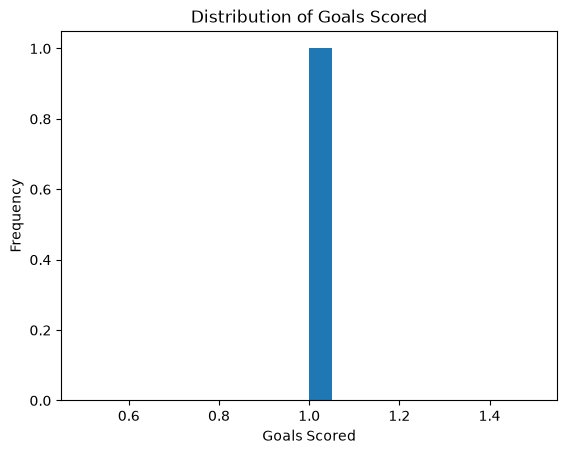

c:\Users\Divine\OneDrive\Desktop\RECESS 2025-26\venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\Divine\OneDrive\Desktop\RECESS 2025-26\venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


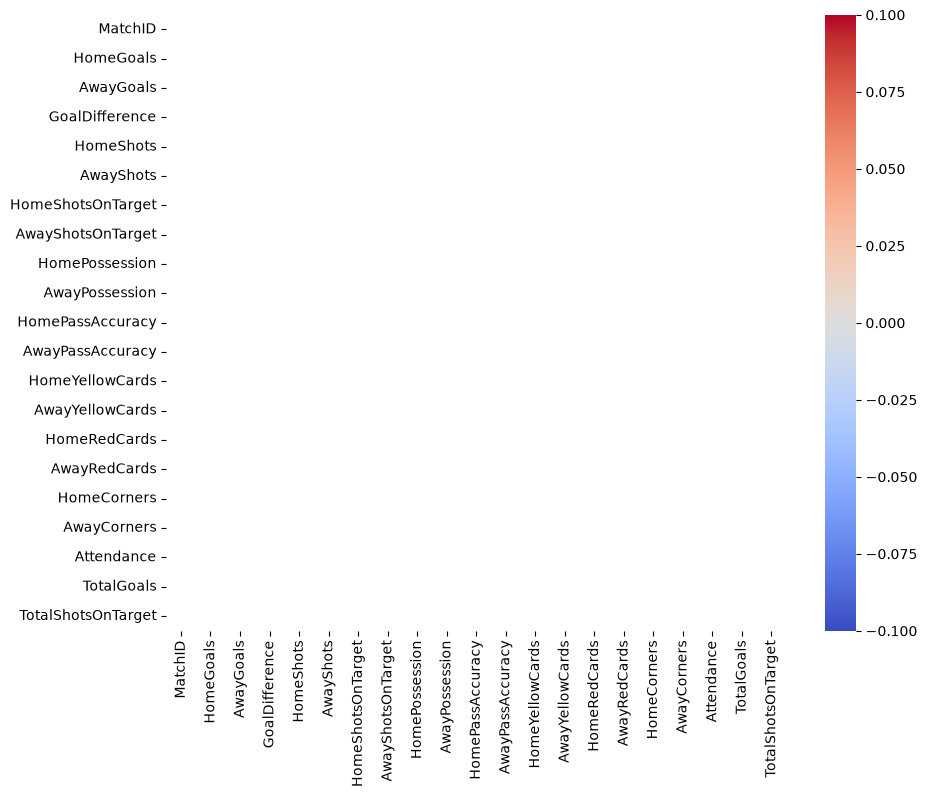

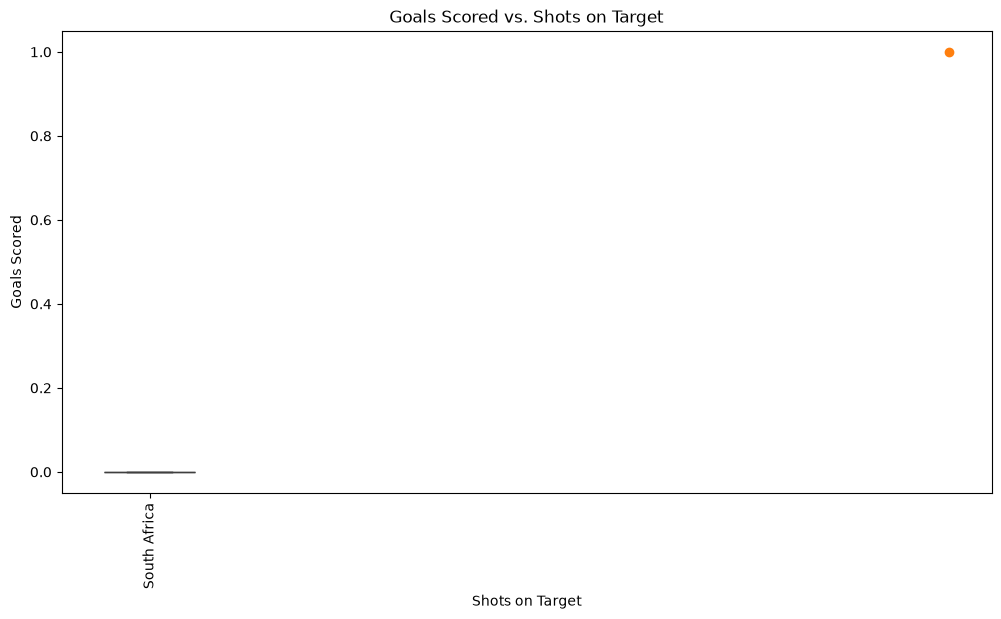

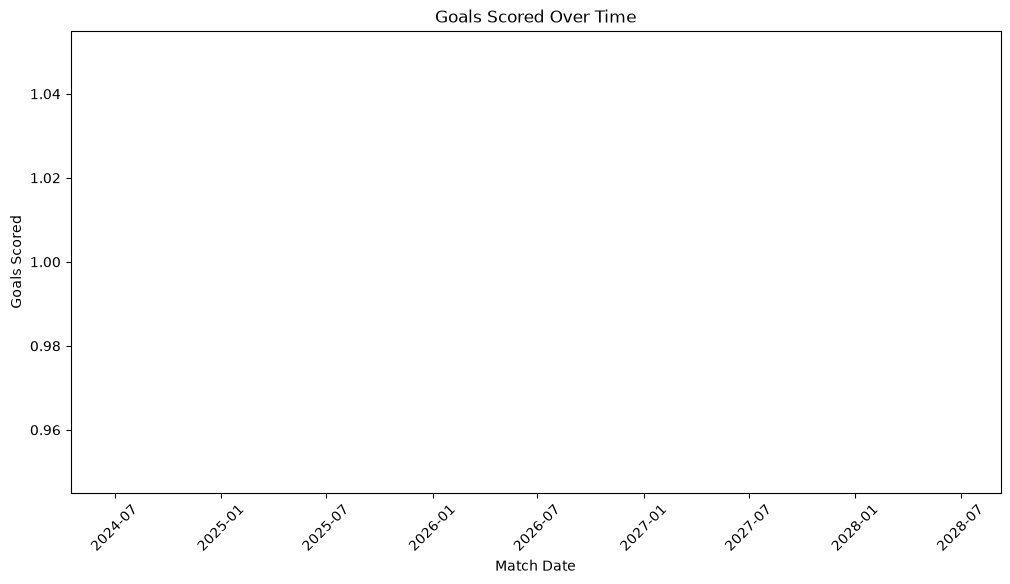

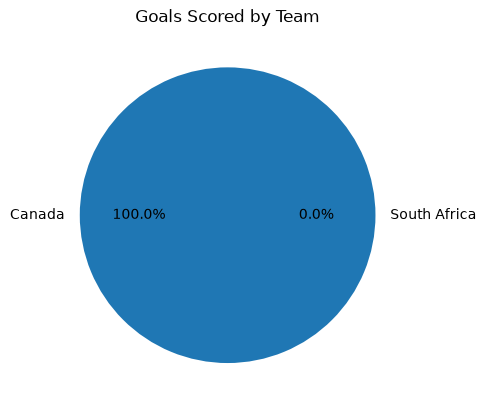

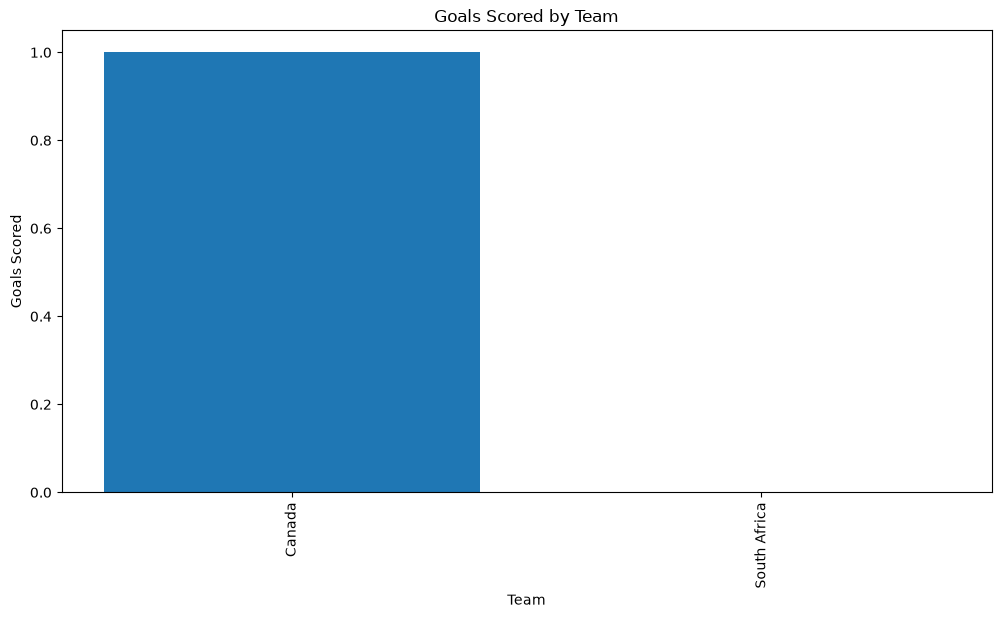

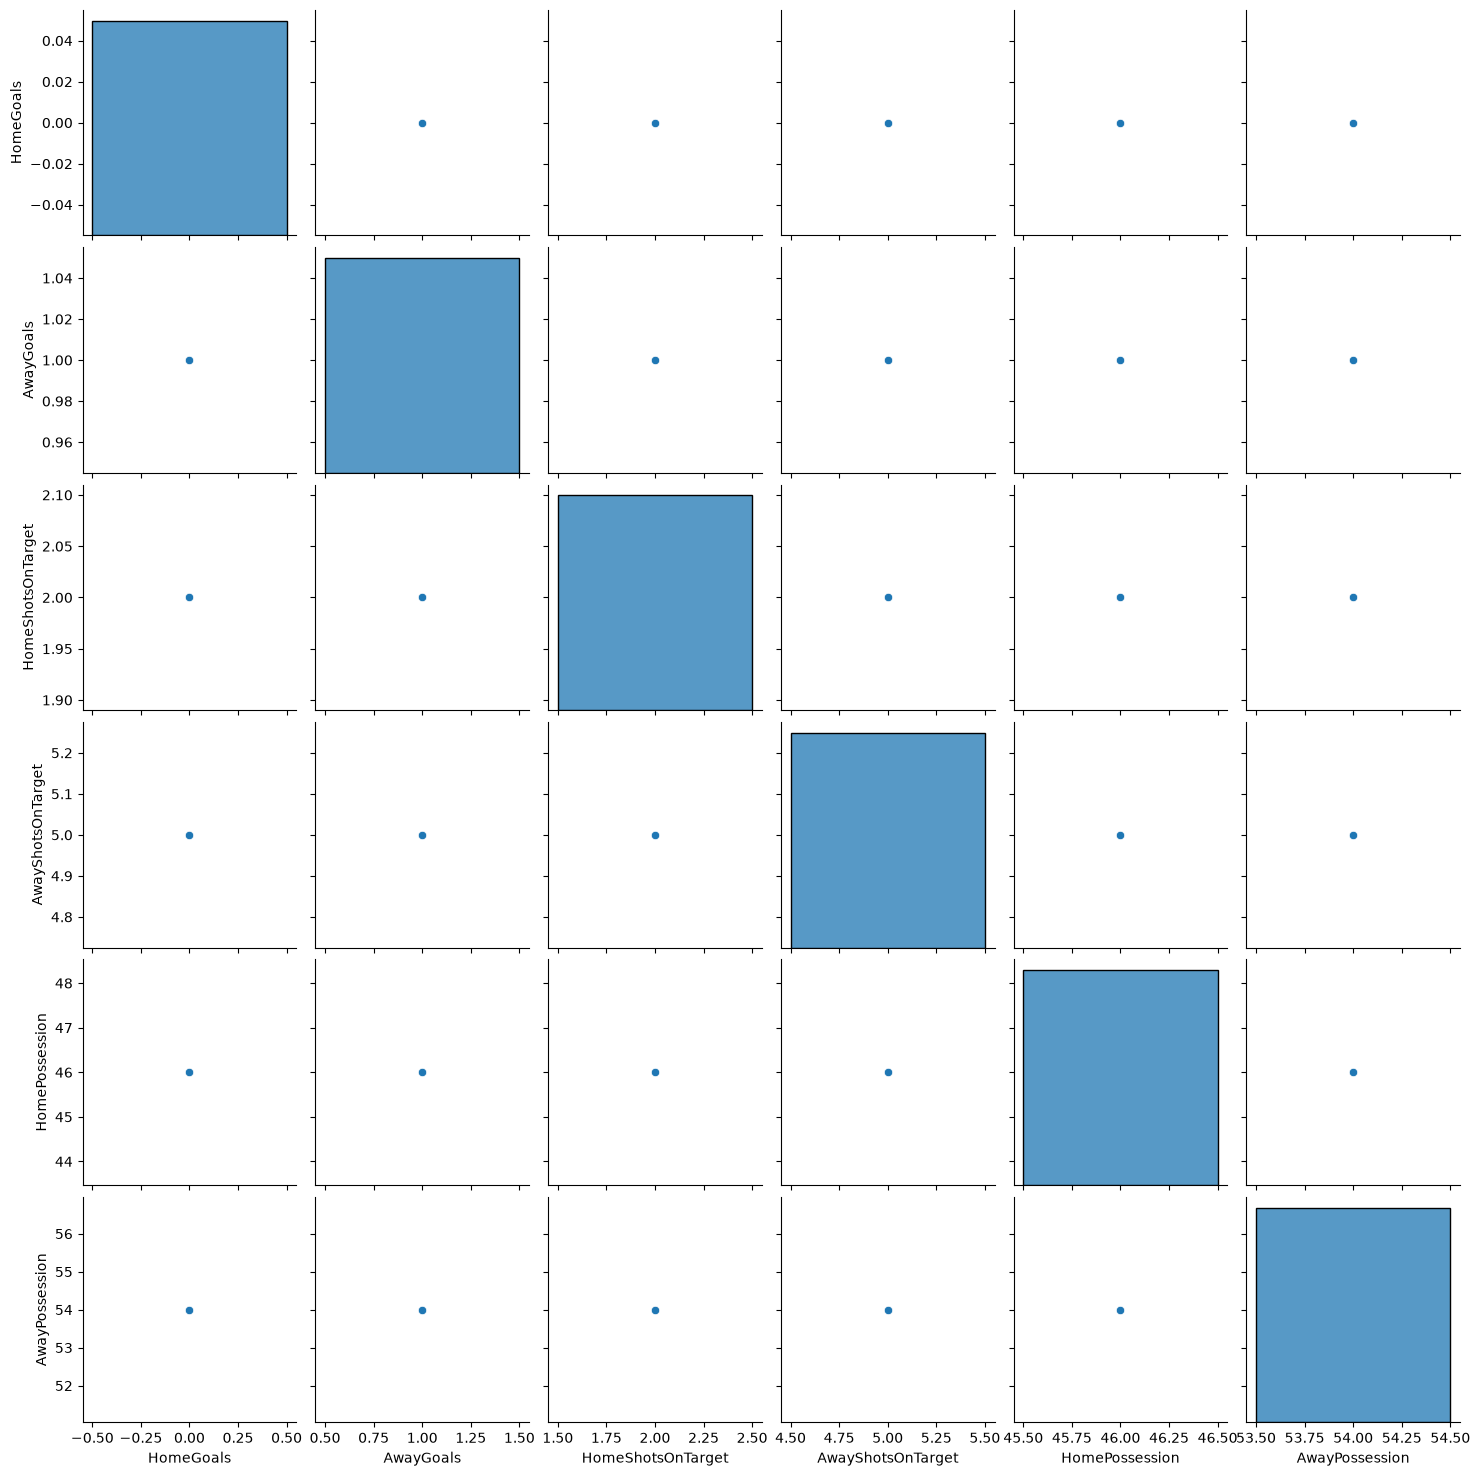

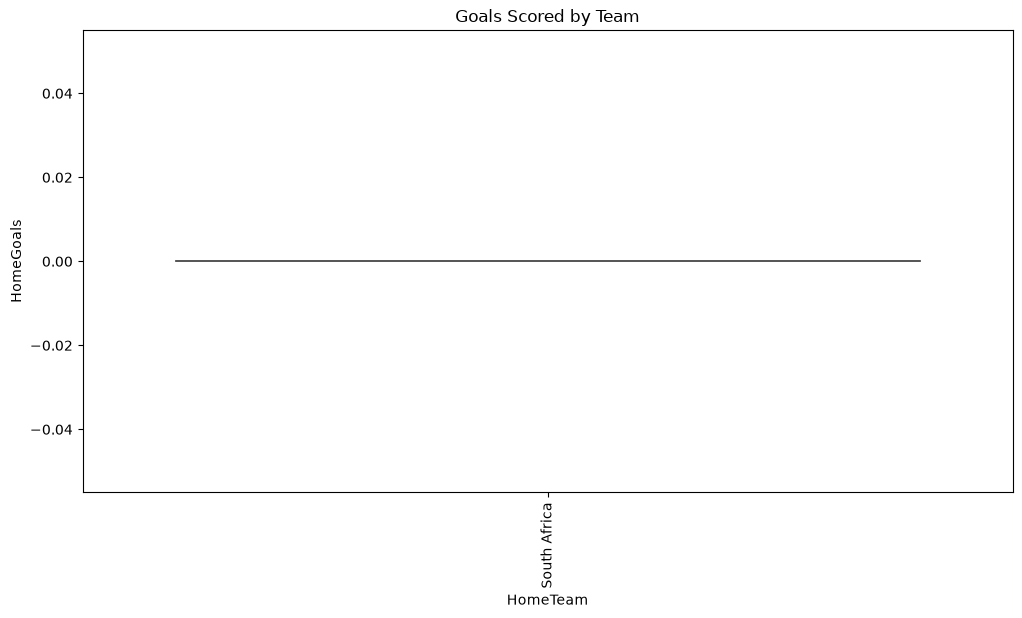

In [9]:
#Data visualization

df['TotalGoals'] = df['HomeGoals'] + df['AwayGoals']
df['TotalShotsOnTarget'] = df['HomeShotsOnTarget'] + df['AwayShotsOnTarget']
df['Date'] = pd.to_datetime(df['Date'])

#1. Distribution of Goals Scored
plt.hist(df['TotalGoals'], bins=20)
plt.xlabel('Goals Scored')
plt.ylabel('Frequency')
plt.title('Distribution of Goals Scored')
plt.show()  

#2. Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')

#3. Boxplot of Goals Scored by Team
import seaborn as sns

plt.figure(figsize=(12, 6)) 
sns.boxplot(x='HomeTeam', y='HomeGoals', data=df)
plt.xticks(rotation=90)

#4. Scatter Plot of Goals Scored vs. Shots on Target
plt.scatter(df['TotalShotsOnTarget'], df['TotalGoals'])
plt.xlabel('Shots on Target')
plt.ylabel('Goals Scored')
plt.title('Goals Scored vs. Shots on Target')
plt.show()

#4. Line Plot of Goals Scored Over Time
df_sorted = df.sort_values('Date')
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['Date'], df_sorted['TotalGoals'])
plt.xlabel('Match Date')
plt.ylabel('Goals Scored')
plt.title('Goals Scored Over Time')
plt.xticks(rotation=45)
plt.show()

#5. Pie Chart of Goals Scored by Team
home_goals_by_team = df.groupby('HomeTeam')['HomeGoals'].sum()
away_goals_by_team = df.groupby('AwayTeam')['AwayGoals'].sum()
team_goals = home_goals_by_team.add(away_goals_by_team, fill_value=0).sort_values(ascending=False)
plt.pie(team_goals, labels=team_goals.index, autopct='%1.1f%%')
plt.title('Goals Scored by Team')   
plt.show()

#6. Bar Plot of Goals Scored by Team
plt.figure(figsize=(12, 6))
plt.bar(team_goals.index, team_goals.values)
plt.xlabel('Team')
plt.ylabel('Goals Scored')
plt.title('Goals Scored by Team')
plt.xticks(rotation=90)
plt.show()

#7. Pair Plot of Goals Scored, Shots on Target, and Possession
sns.pairplot(df[['HomeGoals', 'AwayGoals', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomePossession', 'AwayPossession']])

#8. Violin Plot of Goals Scored by Team
plt.figure(figsize=(12, 6))
sns.violinplot(x='HomeTeam', y='HomeGoals', data=df)
plt.xticks(rotation=90)
plt.title('Goals Scored by Team')
plt.show()  


In [ ]:
#Statistical Analysis
#1. Descriptive Statistics
df.describe()
print("Descriptive statistics of the dataset:")
print(df.describe())

